In [1]:
# ===========================================
# Extract archive.zip
# ===========================================

import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/jena_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

print("\nFiles inside the extracted folder:")
print(os.listdir(extract_path))

Extraction completed!

Files inside the extracted folder:
['jena_climate_2009_2016.csv']


In [2]:
# ===========================================
# Load Jena Climate Dataset
# ===========================================

import pandas as pd
import numpy as np

csv_path = "/content/jena_dataset/jena_climate_2009_2016.csv"

df = pd.read_csv(csv_path)

print("Dataset Shape :", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape : (420551, 15)

First 5 Rows:


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
# ===========================================
# Downsample to Hourly Data
# (Average every 6 consecutive rows)
# ===========================================

# Separate Date column
date_time = df["Date Time"]

# Keep only numerical columns
numeric_df = df.drop(columns=["Date Time"])

# Number of complete groups of 6
num_groups = len(numeric_df) // 6

# Remove leftover rows (if any)
numeric_df = numeric_df.iloc[:num_groups * 6]

# Reshape and average every 6 rows
downsampled = numeric_df.groupby(np.arange(len(numeric_df)) // 6).mean()

# Keep one timestamp per hour
hourly_dates = date_time.iloc[::6].reset_index(drop=True)

downsampled.insert(0, "Date Time", hourly_dates)

print("Original Shape :", df.shape)
print("Hourly Shape   :", downsampled.shape)

display(downsampled.head())

Original Shape : (420551, 15)
Hourly Shape   : (70091, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.523333,-8.261667,265.161667,-9.063333,93.883333,3.271667,3.071667,0.200000,1.918333,3.081667,1308.973333,0.468333,0.940000,177.500000
1,01.01.2009 01:10:00,996.545000,-8.203333,265.221667,-9.026667,93.733333,3.288333,3.081667,0.205000,1.926667,3.093333,1308.713333,0.323333,0.711667,172.016667
2,01.01.2009 02:10:00,996.781667,-8.751667,264.653333,-9.591667,93.583333,3.146667,2.945000,0.200000,1.840000,2.955000,1311.805000,0.236667,0.606667,192.966667
3,01.01.2009 03:10:00,997.011667,-8.936667,264.450000,-9.846667,93.050000,3.101667,2.885000,0.215000,1.803333,2.891667,1313.051667,0.163333,0.565000,169.216667
4,01.01.2009 04:10:00,997.236667,-9.445000,263.923333,-10.450000,92.316667,2.980000,2.751667,0.231667,1.718333,2.756667,1315.951667,0.340000,0.753333,136.260000


In [4]:
# ===========================================
# Normalize the Dataset
# ===========================================

from sklearn.preprocessing import MinMaxScaler

# Remove Date Time column
data = downsampled.drop(columns=["Date Time"])

# Save column names
feature_names = data.columns

# Normalize
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print("Scaled Data Shape :", scaled_data.shape)

print("\nFirst Row:")
print(scaled_data[0])

Scaled Data Shape : (70091, 14)

First Row:
[0.78857154 0.24069875 0.23588188 0.3264287  0.92891317 0.03710013
 0.08290761 0.00445964 0.08076923 0.08158452 0.73823241 0.99874002
 0.99809263 0.49332963]


In [5]:
# ===========================================
# Create Sequences
# ===========================================

INPUT_HOURS = 72
OUTPUT_HOURS = 12

X = []
y = []

# Temperature column index
target_index = list(feature_names).index("T (degC)")

for i in range(len(scaled_data) - INPUT_HOURS - OUTPUT_HOURS):

    X.append(
        scaled_data[i : i + INPUT_HOURS]
    )

    y.append(
        scaled_data[
            i + INPUT_HOURS :
            i + INPUT_HOURS + OUTPUT_HOURS,
            target_index
        ]
    )

X = np.array(X)
y = np.array(y)

print("Input Shape :", X.shape)
print("Output Shape:", y.shape)

Input Shape : (70007, 72, 14)
Output Shape: (70007, 12)


In [6]:
# ===========================================
# Train/Test Split
# ===========================================

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 56005
Testing Samples  : 14002


In [7]:
# ===========================================
# Convert to PyTorch Tensors
# ===========================================

import torch
from torch.utils.data import TensorDataset, DataLoader

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("PyTorch DataLoaders Created Successfully!")

PyTorch DataLoaders Created Successfully!


In [8]:
# ===========================================
# Custom LSTM Cell (Manual Implementation)
# ===========================================

import torch
import torch.nn as nn

class CustomLSTMCell(nn.Module):

    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.hidden_size = hidden_size

        # Input Gate
        self.W_i = nn.Linear(input_size + hidden_size, hidden_size)

        # Forget Gate
        self.W_f = nn.Linear(input_size + hidden_size, hidden_size)

        # Output Gate
        self.W_o = nn.Linear(input_size + hidden_size, hidden_size)

        # Candidate Cell
        self.W_c = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev, c_prev):

        combined = torch.cat((x, h_prev), dim=1)

        # Input Gate
        i = torch.sigmoid(self.W_i(combined))

        # Forget Gate
        f = torch.sigmoid(self.W_f(combined))

        # Output Gate
        o = torch.sigmoid(self.W_o(combined))

        # Candidate Cell
        c_hat = torch.tanh(self.W_c(combined))

        # Cell State Update
        c = f * c_prev + i * c_hat

        # Hidden State Update
        h = o * torch.tanh(c)

        return h, c


print("Custom LSTM Cell Created Successfully!")

Custom LSTM Cell Created Successfully!


In [9]:
# ===========================================
# Custom LSTM Network
# ===========================================

class CustomLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.hidden_size = hidden_size

        self.lstm_cell = CustomLSTMCell(
            input_size=input_size,
            hidden_size=hidden_size
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        batch_size = x.size(0)

        h = torch.zeros(
            batch_size,
            self.hidden_size,
            device=x.device
        )

        c = torch.zeros(
            batch_size,
            self.hidden_size,
            device=x.device
        )

        # Process all 72 time steps
        for t in range(x.size(1)):
            h, c = self.lstm_cell(
                x[:, t, :],
                h,
                c
            )

        output = self.fc(h)

        return output


print("Custom LSTM Network Created Successfully!")

Custom LSTM Network Created Successfully!


In [10]:
# ===========================================
# Test the Custom LSTM
# ===========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomLSTM(
    input_size=14,
    hidden_size=64,
    output_size=12
).to(device)

dummy = torch.randn(8, 72, 14).to(device)

output = model(dummy)

print("Output Shape :", output.shape)

print(model)

Output Shape : torch.Size([8, 12])
CustomLSTM(
  (lstm_cell): CustomLSTMCell(
    (W_i): Linear(in_features=78, out_features=64, bias=True)
    (W_f): Linear(in_features=78, out_features=64, bias=True)
    (W_o): Linear(in_features=78, out_features=64, bias=True)
    (W_c): Linear(in_features=78, out_features=64, bias=True)
  )
  (fc): Linear(in_features=64, out_features=12, bias=True)
)


In [11]:
# ===========================================
# Training Setup
# ===========================================

import torch.optim as optim
import torch.nn as nn

criterion = nn.HuberLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 15

train_losses = []

print("Training Setup Completed!")

Training Setup Completed!


In [12]:
# ===========================================
# Train Custom LSTM
# ===========================================

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for inputs, targets in train_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.6f}")

print("Training Finished!")

Epoch [1/15] Loss: 0.003743
Epoch [2/15] Loss: 0.000781
Epoch [3/15] Loss: 0.000724
Epoch [4/15] Loss: 0.000693
Epoch [5/15] Loss: 0.000673
Epoch [6/15] Loss: 0.000650
Epoch [7/15] Loss: 0.000632
Epoch [8/15] Loss: 0.000617
Epoch [9/15] Loss: 0.000602
Epoch [10/15] Loss: 0.000591
Epoch [11/15] Loss: 0.000579
Epoch [12/15] Loss: 0.000566
Epoch [13/15] Loss: 0.000555
Epoch [14/15] Loss: 0.000550
Epoch [15/15] Loss: 0.000537
Training Finished!


In [13]:
# ===========================================
# Evaluate Custom LSTM
# ===========================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for inputs, targets in test_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        predictions.extend(outputs.cpu().numpy())
        actuals.extend(targets.numpy())

predictions = np.array(predictions)
actuals = np.array(actuals)

mae = mean_absolute_error(
    actuals.flatten(),
    predictions.flatten()
)

mse = mean_squared_error(
    actuals.flatten(),
    predictions.flatten()
)

huber = criterion(
    torch.tensor(predictions),
    torch.tensor(actuals)
).item()

print(f"Huber Loss : {huber:.6f}")
print(f"MAE        : {mae:.6f}")
print(f"MSE        : {mse:.6f}")

Huber Loss : 0.000543
MAE        : 0.024165
MSE        : 0.001087


In [16]:
import matplotlib.pyplot as plt
import numpy as np

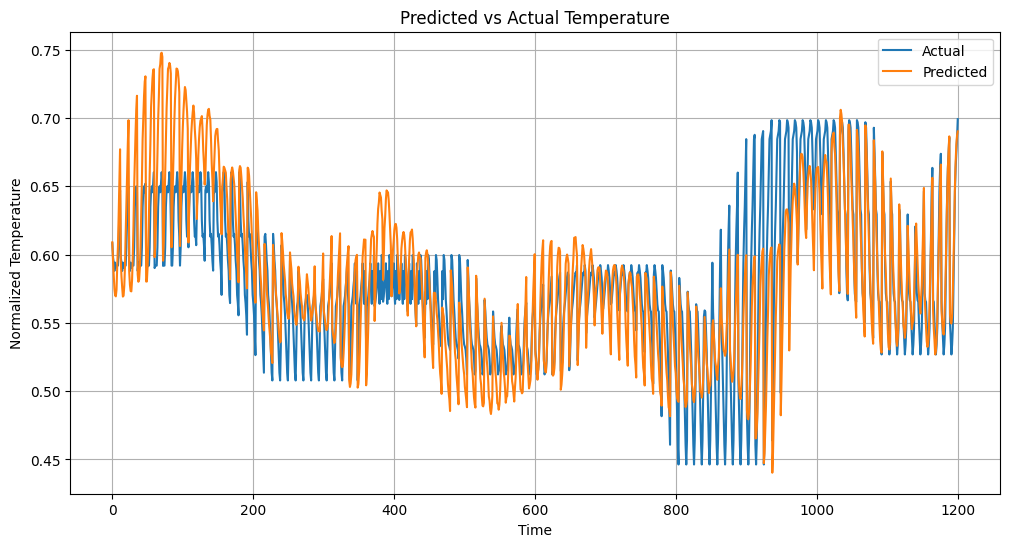

In [17]:
# ===========================================
# Prediction Plot
# ===========================================

plt.figure(figsize=(12,6))

plt.plot(
    actuals[:100].flatten(),
    label="Actual"
)

plt.plot(
    predictions[:100].flatten(),
    label="Predicted"
)

plt.title("Predicted vs Actual Temperature")

plt.xlabel("Time")

plt.ylabel("Normalized Temperature")

plt.legend()

plt.grid(True)

plt.show()

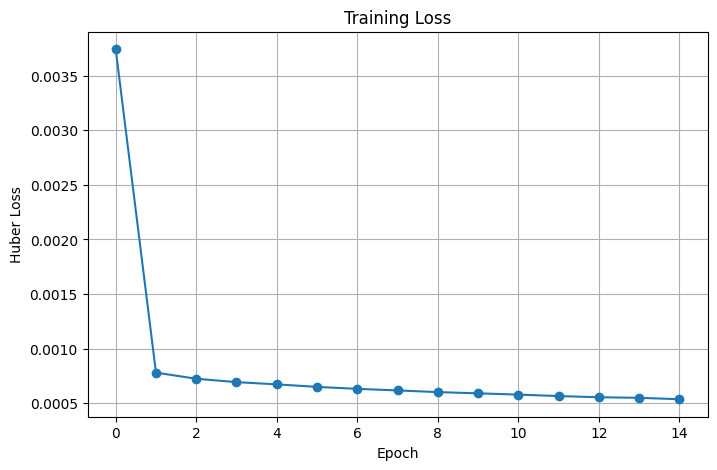

In [18]:
# ===========================================
# Training Loss Curve
# ===========================================

plt.figure(figsize=(8,5))

plt.plot(train_losses, marker="o")

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Huber Loss")

plt.grid(True)

plt.show()

In [19]:
# ===========================================
# Save Model
# ===========================================

torch.save(
    model.state_dict(),
    "custom_lstm.pth"
)

print("Custom LSTM Saved Successfully!")

Custom LSTM Saved Successfully!
